# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "catboost"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.737538,0.262462
1,219.5,0.752344,0.247656
2,220.5,0.766837,0.233163
3,221.5,0.781003,0.218997
4,222.5,0.794827,0.205173


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,239.877493,219,8.945305,222.5,0.026030,9.739701e-01,0,9.739701e-01
1,183.721301,186,9.986033,240.5,1.000000,6.509662e-09,0,6.509662e-09
2,194.989678,192,11.274215,227.5,0.998034,1.965792e-03,0,1.965792e-03
3,193.064257,189,9.926755,230.5,0.999919,8.123339e-05,0,8.123339e-05
4,226.438462,207,9.467711,239.5,0.916143,8.385681e-02,0,8.385681e-02


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.297297,0.295141,74
1,219.5,0.276316,0.254745,76
2,220.5,0.338462,0.185397,65
3,221.5,0.272727,0.276533,66
4,222.5,0.224719,0.225856,89
5,223.5,0.223881,0.174554,67
6,224.5,0.136986,0.120310,73
7,225.5,0.231579,0.165797,95
8,226.5,0.135135,0.131651,74
9,227.5,0.138462,0.137796,65


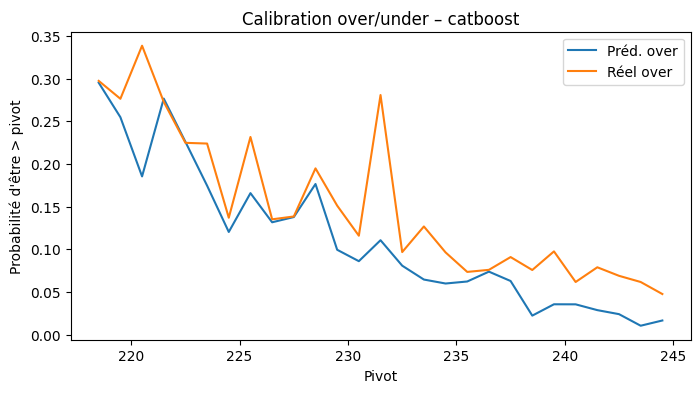

In [3]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [4]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
1153,177.035031,173,244.5,3.441691e-14,1.0,0.5,True
1175,175.771921,161,244.5,4.907186e-14,1.0,0.5,True
790,179.057326,161,234.5,1.907363e-13,1.0,0.5,True
920,180.797271,172,243.5,2.138290e-13,1.0,0.5,True
1375,182.807032,143,242.5,1.151967e-12,1.0,0.5,True
1409,182.115866,164,240.5,1.360023e-12,1.0,0.5,True
799,168.068168,147,236.5,1.384781e-12,1.0,0.5,True
720,176.841296,191,239.5,1.976086e-12,1.0,0.5,True
624,178.284444,191,244.5,1.996292e-12,1.0,0.5,True
1256,184.577032,164,236.5,2.999712e-12,1.0,0.5,True


## Pivot bins (2 pts)

/tmp/ipykernel_307172/1263782636.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 219.5)",74,0.297297,0.295141
1,"[219.5, 220.5)",76,0.276316,0.254745
2,"[220.5, 221.5)",65,0.338462,0.185397
3,"[221.5, 222.5)",66,0.272727,0.276533
4,"[222.5, 223.5)",89,0.224719,0.225856
5,"[223.5, 224.5)",67,0.223881,0.174554
6,"[224.5, 225.5)",73,0.136986,0.120310
7,"[225.5, 226.5)",95,0.231579,0.165797
8,"[226.5, 227.5)",74,0.135135,0.131651
9,"[227.5, 228.5)",65,0.138462,0.137796


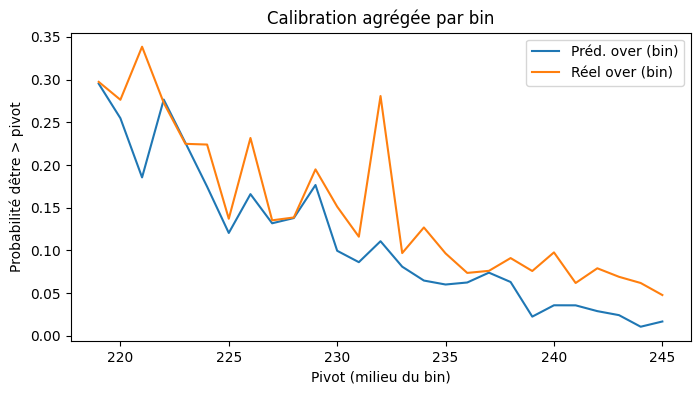

In [11]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=1, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [12]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,1956,0.879346
1,0.10,1907,0.889879
2,0.15,1866,0.897106
3,0.20,1799,0.907171
4,0.25,1723,0.918166


## Distribution des sigma

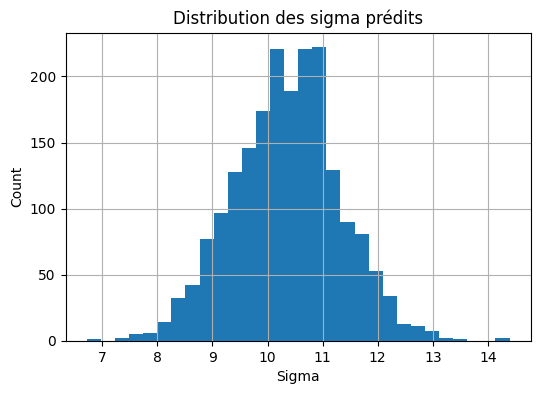

In [13]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
